Exercise - 1


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read and display the image.


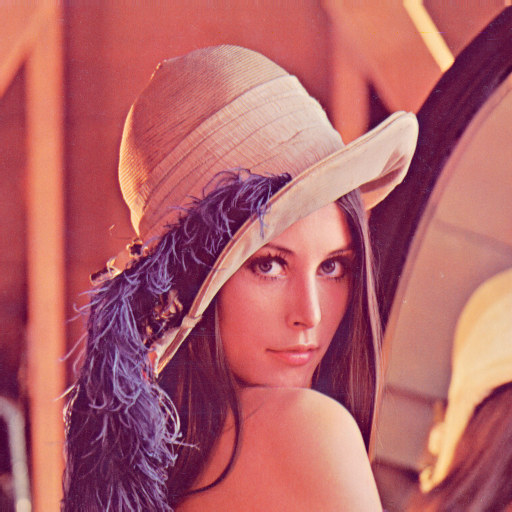

In [21]:
from PIL import Image
image = Image.open("/content/drive/MyDrive/AI_ML/Week1/lena.png")
display(image)


2. Display only the top left corner of 100x100 pixels.

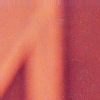

In [22]:
import numpy as np

# Convert image to a NumPy array
image_array = np.array(image)

# Extract the top-left 100x100 pixels
top_left = image_array[:100,:100] #rows(0-99) cols(0-99)

# Convert back to image
top_left_image = Image.fromarray(top_left)
display(top_left_image)


3. Show the three color channels (R, G, B).

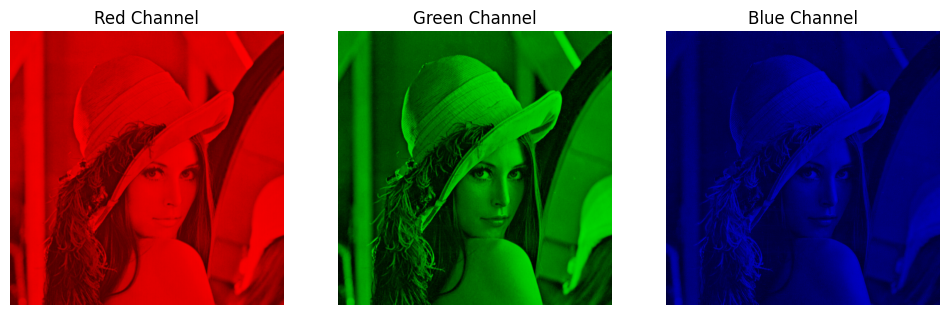

In [28]:
import matplotlib.pyplot as plt

#Seperate the color channels
R = image_array.copy()
G = image_array.copy()
B = image_array.copy()

#Zero out the other channels

# Red
R[:, :, 1]  = 0  # Zero green
R[:, :, 2] = 0  # Zero blue

# Green
G[:, :, 0]  = 0  # Zero Red
G[:, :, 2] = 0  # Zero blue

# Blue
B[:, :, 0]  = 0  # Zero Red
B[:, :, 1] = 0  # Zero Green

# Convery back to image
R_image = Image.fromarray(R)
G_image = Image.fromarray(G)
B_image = Image.fromarray(B)

# Display all channels

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(R_image)
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(G_image)
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(B_image)
plt.title('Blue Channel')
plt.axis('off')

plt.show()


4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image

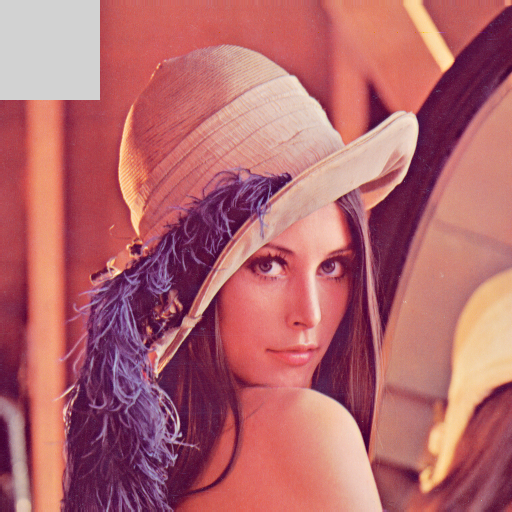

In [32]:

image_array[:100,:100] = 210
modified_image = Image.fromarray(image_array)
display(modified_image)

Exercise - 2:

1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

In [47]:
# Helper function to display images
def show_image(img, title="", cmap_type=None):
    """
    Displays an image using matplotlib.

    Parameters:
        img : PIL.Image or NumPy array
        title : str - title of the image
        cmap_type : str or None - color map, e.g., 'gray' for grayscale
    """
    # Convert PIL Image to NumPy array if needed
    if isinstance(img, Image.Image):
        img = np.array(img)

    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

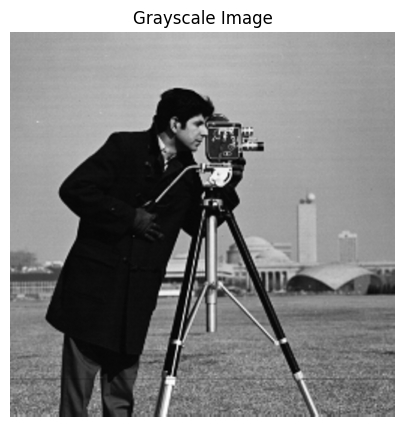

In [48]:
img_grayscale = Image.open("/content/drive/MyDrive/AI_ML/Week1/cameraman.png")
show_image(img_grayscale, title="Grayscale Image", cmap_type="gray")


2. Extract and display the middle section of the image (150 pixels).

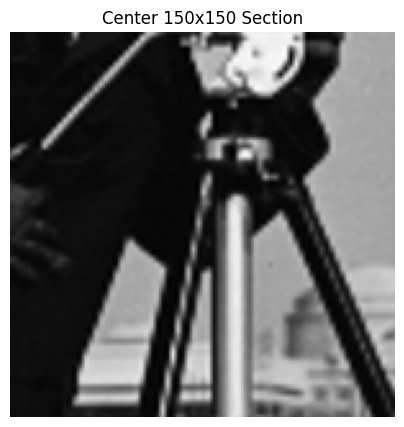

In [49]:
img_grayscale_array = np.array(img_grayscale)
height , width = img_grayscale_array.shape
center_crop = img_grayscale_array[height//2 - 75: height//2 + 75, width//2 - 75 : width//2 +75]

show_image(center_crop, title="Center 150x150 Section", cmap_type="gray")

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.

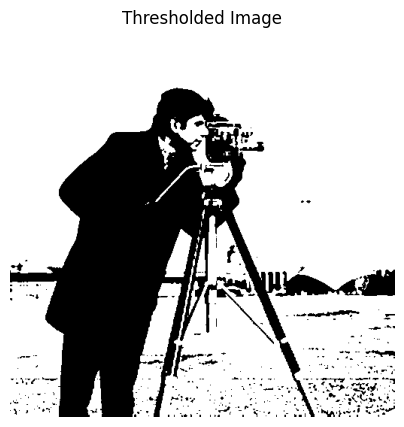

In [50]:
binary_image = np.where(img_grayscale_array < 100, 0, 255).astype(np.uint8)
show_image(binary_image, title="Thresholded Image", cmap_type="gray")

4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.

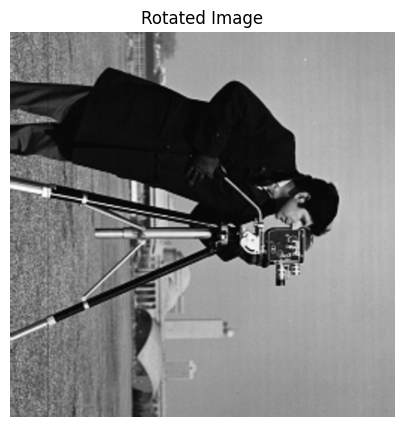

In [51]:
rotated_image = img_grayscale.rotate(-90, expand=True)  # Negative for clockwise rotation

show_image(rotated_image, title="Rotated Image", cmap_type="gray")

5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

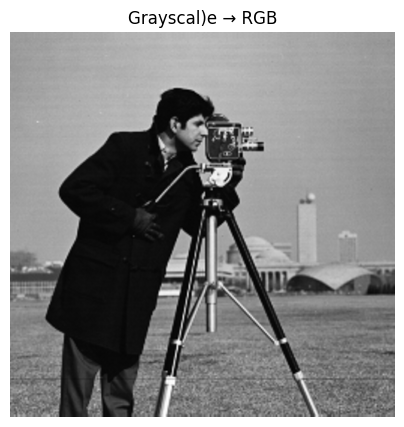

In [52]:
rgb_image = Image.merge("RGB", (img_grayscale, img_grayscale, img_grayscale))  # Replicate grayscale across R,G,B

show_image(rgb_image, title="Grayscal)e → RGB", cmap_type="gray")

3 Image Compression and Decompression using PCA.

1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.

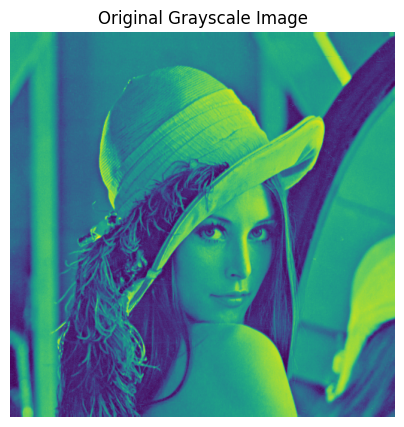

In [56]:
coloured_image = image
gray_image = coloured_image.convert('L')
show_image(gray_image, "Original Grayscale Image")

In [58]:
image_array = np.array(gray_image)
height , width = image_array.shape
data = image_array.reshape( height , width )


Standardize the Data:

In [59]:
# Compute the mean of each column ( feature )
mean = np.mean(data, axis=0)

# Center the data by subtracting the mean from each column
centered_data = data - mean

Compute Covariance Matrix:

In [60]:
cov_matrix = np.cov ( centered_data , rowvar = False )

2. Eigen Decomposition and Identifying Principal Components:



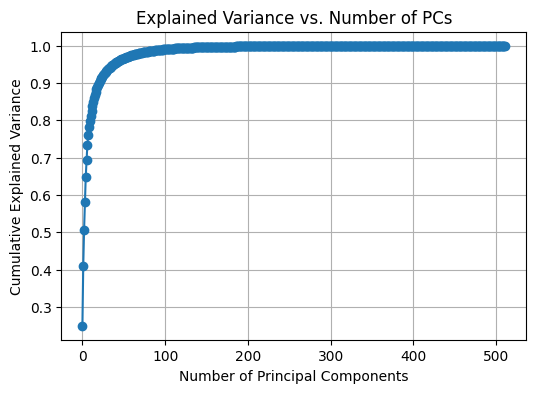

In [67]:
# Eigen decomposition
eig_values, eig_vectors = np.linalg.eigh(cov_matrix)  # For symmetric cov matrix

# Sort eigenvalues descending
sorted_idx = np.argsort(eig_values)[::-1]
eig_values = eig_values[sorted_idx]
eig_vectors = eig_vectors[:, sorted_idx]

# Explained variance ratio
explained_variance_ratio = eig_values / np.sum(eig_values)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of PCs")
plt.grid(True)
plt.show()

3: Image Reconstruction with Selected PCs

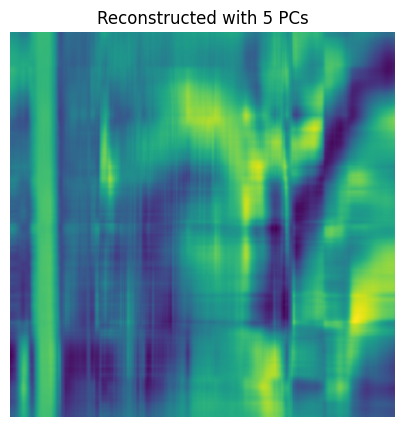

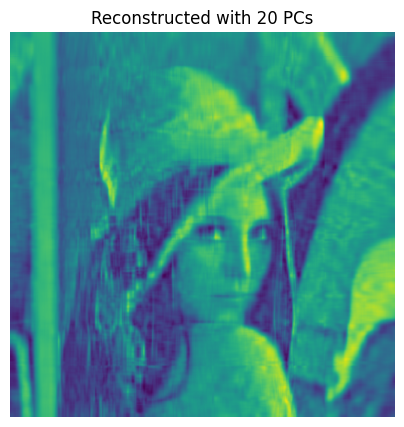

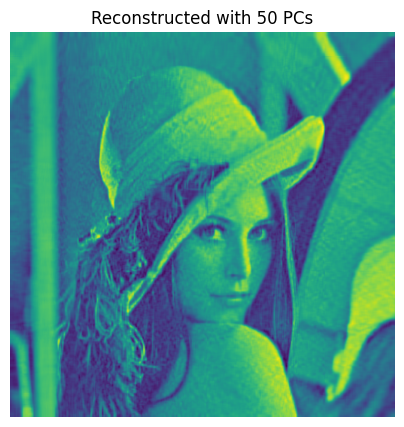

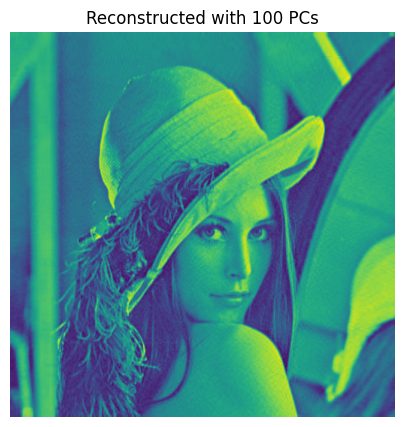

In [70]:
def reconstruct_image(X_centered, eig_vectors, num_pcs):
    """Reconstruct image using top num_pcs principal components."""
    # Select top k eigenvectors
    PCs = eig_vectors[:, :num_pcs]

    # Project data to lower-dimensional space
    X_reduced = X_centered @ PCs

    # Reconstruct back to original space
    X_reconstructed = X_reduced @ PCs.T + mean
    return X_reconstructed

# Experiment with different number of PCs
pcs_list = [5, 20, 50, 100]  # Example choices
for k in pcs_list:
    reconstructed = reconstruct_image(centered_data, eig_vectors, k)
    show_image(np.clip(reconstructed, 0, 255), title=f"Reconstructed with {k} PCs")

Evaluation

In [75]:
from skimage.metrics import peak_signal_noise_ratio as psnr

for k in pcs_list:
    reconstructed = reconstruct_image(centered_data, eig_vectors, k)

    # Clip and convert to uint8
    reconstructed_uint8 = np.clip(reconstructed, 0, 255).astype(np.uint8)
    original_uint8 = image_array.astype(np.uint8)

    psnr_val = psnr(original_uint8, reconstructed_uint8)
    print(f"PSNR for {k} PCs: {psnr_val:.2f}")

PSNR for 5 PCs: 20.19
PSNR for 20 PCs: 25.46
PSNR for 50 PCs: 30.26
PSNR for 100 PCs: 35.66
